In [1]:
from google.colab import files
files.upload()   # upload kaggle.json here

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"sreedevinarayan","key":"42699bc1600bded69a9e3db3fe661a92"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d arkantaha/ethereum-phishing-scams-dataset-ethpsd

Dataset URL: https://www.kaggle.com/datasets/arkantaha/ethereum-phishing-scams-dataset-ethpsd
License(s): other
ethereum-phishing-scams-dataset-ethpsd.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip ethereum-phishing-scams-dataset-ethpsd.zip

Archive:  ethereum-phishing-scams-dataset-ethpsd.zip
replace 1st complete balanced dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace 1st dataset - imbalanced.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace details about collecting.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [6]:
import pandas as pd
df = pd.read_csv("1st complete balanced dataset.csv")
df.head()

,TxHash,BlockHeight,TimeStamp,From,To,Value,ContractAddress,Input,Class
0,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,NaN,0x,0
1,0x95681862f9778e49caecf603dd911d6ed57f7799d89d...,5848181,1529875104,0xe7e07e44ee315b5f2d076340b2b7a5cc9a4ee57b,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.001020,NaN,0x,0
2,0x716ae3961b50186a0bbc272cfcc4555662f7fe33550f...,5848716,1529883192,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.500390,NaN,0x,0
3,0xf397197b800d6cc055a4db265b5e9df3dd2aa745c813...,5849038,1529887684,0x0681d8db095565fe8a346fa0277bffde9c0edbbf,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.817800,NaN,0x,0
4,0x7f8086011a32f128dba57fe06fc5f4a181d2f5401e5a...,5849437,1529893144,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.817506,NaN,0x,0


In [7]:
df = pd.read_csv("1st dataset - imbalanced.csv")
df.head()

,TxHash,BlockHeight,TimeStamp,From,To,Value,ContractAddress,Input,Class
0,0xaca3850ba0080cf47b47f80e46da452f61bcbb5470d3...,5848095,1529873859,0x16f209b5332a1b4fa5bf19497ca40154c5db2f85,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.500000,NaN,0x,0
1,0x95681862f9778e49caecf603dd911d6ed57f7799d89d...,5848181,1529875104,0xe7e07e44ee315b5f2d076340b2b7a5cc9a4ee57b,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.001020,NaN,0x,0
2,0x716ae3961b50186a0bbc272cfcc4555662f7fe33550f...,5848716,1529883192,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.500390,NaN,0x,0
3,0xf397197b800d6cc055a4db265b5e9df3dd2aa745c813...,5849038,1529887684,0x0681d8db095565fe8a346fa0277bffde9c0edbbf,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0.817800,NaN,0x,0
4,0x7f8086011a32f128dba57fe06fc5f4a181d2f5401e5a...,5849437,1529893144,0x002f0c8119c16d310342d869ca8bf6ace34d9c39,0xe892875b87b94c44edf0e91ee9f49d0525fadd83,0.817506,NaN,0x,0


In [8]:
balanced = pd.read_csv("1st complete balanced dataset.csv")
imbalanced = pd.read_csv("1st dataset - imbalanced.csv")

print("Balanced columns:\n", balanced.columns.tolist())
print("\nImbalanced columns:\n", imbalanced.columns.tolist())

Balanced columns:
 ['TxHash', 'BlockHeight', ' TimeStamp', 'From', 'To', 'Value', 'ContractAddress', 'Input', 'Class']

Imbalanced columns:
 ['TxHash', 'BlockHeight', ' TimeStamp', 'From', 'To', 'Value', 'ContractAddress', 'Input', 'Class']


In [9]:
balanced.columns = balanced.columns.str.strip()
imbalanced.columns = imbalanced.columns.str.strip()

In [10]:
label_col = "Class"
print(balanced[label_col].value_counts(), "\n")
print(imbalanced[label_col].value_counts())

Class
0    79216
1    38143
Name: count, dtype: int64 

Class
0    79216
1     5449
Name: count, dtype: int64


In [11]:
combined = pd.concat([balanced, imbalanced], ignore_index=True)
combined.drop_duplicates(inplace=True)
combined.reset_index(drop=True, inplace=True)

print("Final combined shape:", combined.shape)
print(combined[label_col].value_counts())

Final combined shape: (84080, 9)
Class
0    78631
1     5449
Name: count, dtype: int64


PREPROCESSING (drop useless columns)

In [12]:
drop_cols = ["TxHash", "From", "To", "ContractAddress", "Input"]
drop_cols = [c for c in drop_cols if c in combined.columns]

df = combined.drop(columns=drop_cols)

Convert timestamps & numeric features

In [13]:
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], unit="s", errors="coerce")
df["BlockHeight"] = pd.to_numeric(df["BlockHeight"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df.dropna()

Feature Extraction

In [14]:
df["hour"] = df["TimeStamp"].dt.hour
df["day"] = df["TimeStamp"].dt.day
df["month"] = df["TimeStamp"].dt.month
df["weekday"] = df["TimeStamp"].dt.weekday

In [15]:
df = df.drop(columns=["TimeStamp"])

SPLIT FEATURES & LABEL

In [16]:
X = df.drop(columns=[label_col])
y = df[label_col].astype(int)

TRAIN–TEST SPLIT + SCALING

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

SMOTE (for imbalanced data)

In [18]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)

X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

TRAIN 6 ML MODELS

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "MLP": MLPClassifier(hidden_layer_sizes=(64,32), max_iter=300)
}

print("\nMODEL PERFORMANCE:\n")
results = {}

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

print("\nSORTED RESULTS:")
for m, a in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{m}: {a:.4f}")


MODEL PERFORMANCE:

Decision Tree: 0.9326
Random Forest: 0.9409
Gradient Boosting: 0.8606
KNN: 0.9187
SVM: 0.8838
MLP: 0.8465

SORTED RESULTS:
Random Forest: 0.9409
Decision Tree: 0.9326
KNN: 0.9187
SVM: 0.8838
Gradient Boosting: 0.8606
MLP: 0.8465


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


SHAP Explainability for Best Model (Random Forest)

In [21]:
import shap

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]
explainer = shap.TreeExplainer(best_model, X_train)

In [ ]:
shap_values = explainer(X_test)

  5%|=                   | 2568/50448 [05:35<104:06]       

In [22]:
import numpy as np

print(type(shap_values))
print(np.array(shap_values.values).shape)

NameError: name 'shap_values' is not defined

In [ ]:
import pandas as pd

feature_names = X.columns  # Save original feature columns

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)


In [ ]:
X_sample = X_train_df.sample(2000, random_state=42)


In [ ]:
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)


The SHAP plots reveal which transaction patterns push a prediction toward fraud, making the system transparent.

In [ ]:
# Pick class index 1 (fraud)
shap_class1 = shap_values[:,:,1]   # (2000, n_features)

shap.summary_plot(shap_class1, X_sample, max_display=20)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

# Classification Report
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = {:.4f}".format(roc_auc))
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [24]:
print(df['TimeStamp'].head())


KeyError: 'TimeStamp'

In [ ]:
print(df['TimeStamp'].min())
print(df['TimeStamp'].max())


In [ ]:
import shap
import numpy as np

# ⚡ Speed-up: sample only 2000 rows for SHAP
sample_size = 2000

# X_train is a numpy array, so it doesn't have a .sample() method.
# We need to sample rows using numpy's random capabilities.
# Set numpy random seed for reproducibility
np.random.seed(42)

if X_train.shape[0] > sample_size:
    # Get random indices without replacement
    idx = np.random.choice(X_train.shape[0], sample_size, replace=False)
    X_sample = X_train[idx]
else:
    # If X_train has fewer samples than sample_size, use all of X_train
    X_sample = X_train

best_model = RandomForestClassifier(n_estimators=300, random_state=42)
best_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

# --- Debugging print statements ---
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Length of shap_values list: {len(shap_values)}")
    for i, arr in enumerate(shap_values):
        print(f"Shape of shap_values[{i}]: {arr.shape}")
elif isinstance(shap_values, np.ndarray):
    print(f"Shape of shap_values array: {shap_values.shape}")

print(f"Shape of X_sample: {X_sample.shape}")
# --- End Debugging print statements ---

# Based on typical TreeExplainer output for binary classification,
# shap_values is a list where index 1 contains the SHAP values for the positive class.
# We will use shap_values[1] assuming it's a list of arrays.
shap.summary_plot(shap_values[1], X_sample, max_display=20)

In [25]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [26]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')  # use softmax for multi-class
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',   # categorical_crossentropy for multi-class
    metrics=['accuracy']
)

In [28]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9230 - loss: 0.2356 - val_accuracy: 0.9345 - val_loss: 0.1882
Epoch 2/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9379 - loss: 0.1846 - val_accuracy: 0.9342 - val_loss: 0.1821
Epoch 3/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9377 - loss: 0.1811 - val_accuracy: 0.9362 - val_loss: 0.1792
Epoch 4/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9387 - loss: 0.1759 - val_accuracy: 0.9365 - val_loss: 0.1751
Epoch 5/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9363 - loss: 0.1769 - val_accuracy: 0.9357 - val_loss: 0.1734
Epoch 6/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9375 - loss: 0.1727 - val_accuracy: 0.9381 - val_loss: 0.1705
Epoch 7/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9381 - loss: 0.1751 - val_accuracy: 0.9375 - val_loss: 0.1694
Epoch 8/30
1472/1472 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9378 - loss: 0.1712 - 

In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

789/789 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9457 - loss: 0.1520
Test Accuracy: 0.943981945514679


In [30]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

789/789 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     23589
           1       0.64      0.31      0.42      1635

    accuracy                           0.94     25224
   macro avg       0.80      0.65      0.70     25224
weighted avg       0.93      0.94      0.93     25224

[[23300   289]
 [ 1124   511]]


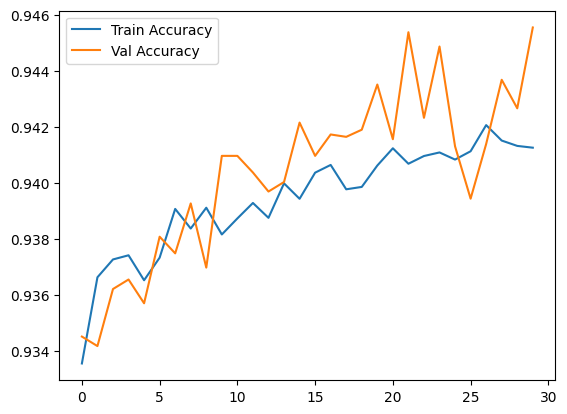

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

In [32]:
!pip install shap

In [33]:
import numpy as np

X_test_np = np.array(X_test)

In [ ]:
import shap
import numpy as np

# background data
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

# explainer
explainer = shap.DeepExplainer(model, background)

# SHAP values
shap_values = explainer.shap_values(np.array(X_test))

# convert X_test explicitly
X_test_np = np.array(X_test)

# feature names
feature_names = X.columns.tolist()

# summary plot
shap.summary_plot(
    shap_values[0],
    X_test_np,
    feature_names=feature_names
)

In [40]:
df.columns.tolist()

['BlockHeight', 'Value', 'Class', 'hour', 'day', 'month', 'weekday']

In [41]:
blockchain_features = [
    'BlockHeight',   # position of transaction in blockchain
    'Value'          # Ether value transferred
]
temporal_features = [
    'hour',     # hour of transaction
    'day',      # day of month
    'month',    # month of transaction
    'weekday'   # day of week
]


In [42]:
X_ablate_block = X.drop(columns=blockchain_features)

In [43]:
X_ablate_time = X.drop(columns=temporal_features)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


In [45]:
model_full = build_model(X_train.shape[1])
model_full.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

baseline_acc = model_full.evaluate(X_test, y_test, verbose=0)[1]
print("Baseline Accuracy:", baseline_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Baseline Accuracy: 0.9391452670097351


In [46]:
X_ablate = X.drop(columns=blockchain_features)

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_ablate, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_a = scaler.fit_transform(X_train_a)
X_test_a = scaler.transform(X_test_a)

model_ablate = build_model(X_train_a.shape[1])
model_ablate.fit(X_train_a, y_train_a, epochs=10, batch_size=32, verbose=0)

ablate_acc = model_ablate.evaluate(X_test_a, y_test_a, verbose=0)[1]
print("Accuracy after removing transaction features:", ablate_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy after removing transaction features: 0.9405328035354614


In [47]:
def build_model_no_dropout(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        Dense(64, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
